In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

In [2]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

### 데이터 불러오기(구글 2015~2018년도)

In [24]:
# Yahoo Finance에서 수집한 CSV
file_path = "../Data-collection/dailyStock"
target = "GOOG"
file_path = f"{file_path}/{target}.csv"
df = pd.read_csv(file_path, encoding="utf-8")

df['Date'] = pd.to_datetime(df['Date']) # 날짜로 변환
df = df.set_index('Date')               # Date를 인덱스로 설정
df = df.loc['2015-01-01':'2019-03-31']  # 분석 기간



train_indices = df.index.year < 2019
goog = df[train_indices]
test = df[~train_indices]

goog= goog.resample('W').last().adj_close
test= test.resample('W').last().adj_close

n_forecasts = len(test)

### auto_arima 기본 설정

In [25]:
auto_arima = pm.auto_arima(goog, 
                           error_action='ignore',
                           suppress_warnings=True,
                           seasonal=False)
auto_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  210
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -364.941
Date:                Thu, 17 Sep 2026   AIC                            735.883
Time:                        00:26:21   BIC                            745.910
Sample:                    01-04-2015   HQIC                           739.937
                         - 01-06-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1226      0.074      1.667      0.095      -0.022       0.267
ma.L1         -0.2368      0.069     -3.423      0.001      -0.372      -0.101
sigma2         1.9234      0.109     17.575      0.000       1.709       2.138
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):               133.58
Prob(Q):                              0.80   Prob(JB):                         0.00
Heteroskedasticity (H):               1.89   Skew:                             0.05
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### auto_arima 매개 변수 조정

In [26]:
auto_arima = pm.auto_arima(goog,
                           error_action='ignore',
                           suppress_warnings=True,
                           seasonal=False,
                           stepwise=False,
                           approximation=False,
                           n_jobs=-1)
auto_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  210
Model:               SARIMAX(3, 1, 2)   Log Likelihood                -358.908
Date:                Thu, 17 Sep 2026   AIC                            731.815
Time:                        00:26:35   BIC                            755.211
Sample:                    01-04-2015   HQIC                           741.274
                         - 01-06-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4989      0.308      1.619      0.105      -0.105       1.103
ar.L1         -1.5418      0.137    -11.226      0.000      -1.811      -1.273
ar.L2         -1.1796      0.137     -8.606      0.000      -1.448      -0.911
ar.L3         -0.3004      0.067     -4.487      0.000      -0.432      -0.169
ma.L1          1.3598      0.140      9.730      0.000       1.086       1.634
ma.L2          0.7916      0.132      5.993      0.000       0.533       1.050
sigma2         1.8121      0.123     14.786      0.000       1.572       2.052
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               119.82
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.81   Skew:                             0.09
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 모델 예측

In [27]:
pred, conf_int = auto_arima.predict(n_periods=n_forecasts, return_conf_int=True, alpha=0.05)

auto_arima_pred = pd.DataFrame({
        'prediction': pred,
        'ci_lower': conf_int[:, 0],
        'ci_upper': conf_int[:, 1]
    })

auto_arima_pred.index = test.index

In [28]:
arima = ARIMA(goog, order=(2, 1, 1)).fit()


arima_forecast = arima.get_forecast(steps=n_forecasts)

prediction = arima_forecast.predicted_mean
confidence_interval = arima_forecast.conf_int()

arima_pred = pd.DataFrame({
    'prediction': prediction,
    'ci_lower': confidence_interval.iloc[:, 0],
    'ci_upper': confidence_interval.iloc[:, 1]
})

arima_pred.index = test.index

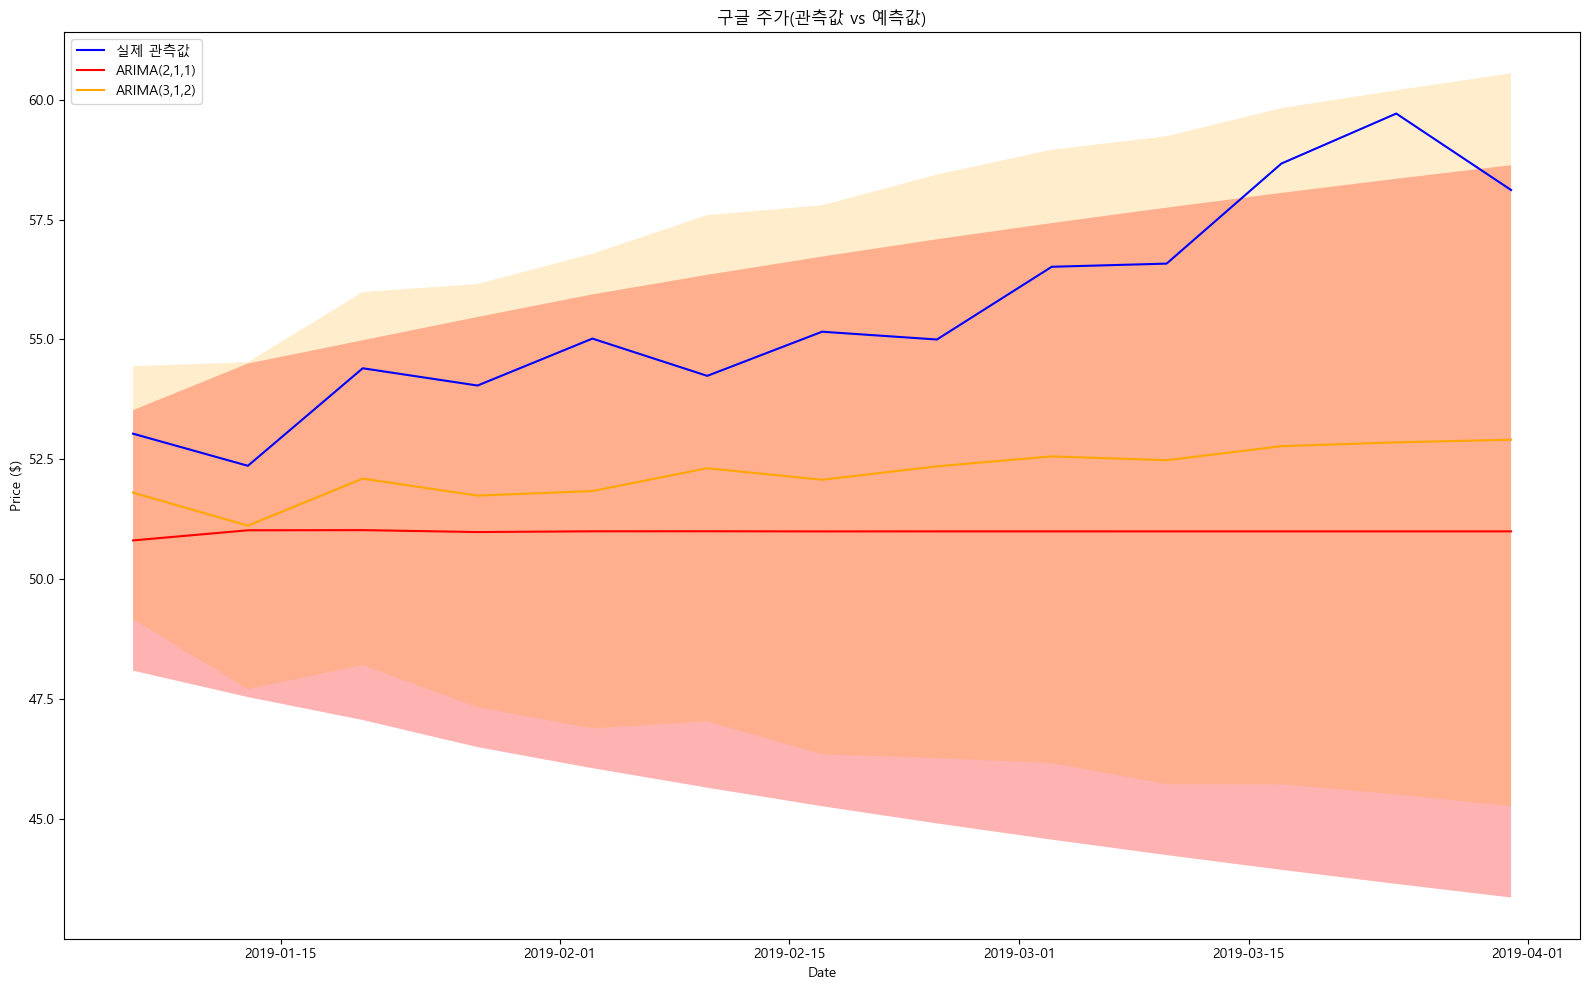

In [31]:
fig, ax = plt.subplots(1, figsize=(16, 10))

ax = sns.lineplot(data=test, color="blue", label='실제 관측값')

ax.plot(arima_pred.prediction, c="red", label='ARIMA(2,1,1)')
ax.fill_between(arima_pred.index,
                arima_pred.ci_lower,
                arima_pred.ci_upper,
                alpha=0.3, 
                facecolor="red")

ax.plot(auto_arima_pred.prediction, c="orange", 
        label='ARIMA(3,1,2)')
ax.fill_between(auto_arima_pred.index,
                auto_arima_pred.ci_lower,
                auto_arima_pred.ci_upper,
                alpha=0.2, 
                facecolor="orange")

ax.set(title="구글 주가(관측값 vs 예측값)", 
       xlabel='Date', 
       ylabel='Price ($)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()